# 3Di alignment benchmark

## Description

We compare the performance of ESM3Di, compared to ProstT5, on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* `AF3`: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* `ProstT5`: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* `ESM3Di`: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database, run Foldseek `structurealign` module with 1-vs-1 basis (aligning identical entries).

The results are represented as the bitscore of the alignment, and 3Di sequence identity, which can be calculated as: 
$\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}$

---

## Database preparation

### Download and process the MetaVR dataset

In [ ]:
%%bash
# Download MetaVR dataset
mkdir -p data/metavr
wget -q -O data/metavr/IMGVR5_PC_3Dmodels.tar.gz "https://www.meta-virome.org/Data/Downloads/IMGVR5_PC_3Dmodels.tar.gz"
tar -xzf data/metavr/IMGVR5_PC_3Dmodels.tar.gz -C data/metavr

# Create Foldseek database
mkdir -p data/foldseek
foldseek createdb data/metavr/metaVR_structures_all data/foldseek/metavr_af3

### Predict 3Di representations with ProstT5

#### Generate AA FASTA file from the MetaVR dataset

In [ ]:
%%bash
awk '{gsub(/\x00/, "", $0)} NR==FNR{f[FNR]=$0; next} f[FNR]{print ">"f[FNR]"\n"$0}' \
    data/foldseek/metavr_af3_h \
    data/foldseek/metavr_af3 \
    > data/metavr/metavr_aa.fa

#### Predict 3Di with ProstT5

In [ ]:
%%bash
foldseek databases ProstT5 data/prostt5_weights data/tmp
rm -rf data/tmp
foldseek createdb data/metavr/metavr_aa.fa data/foldseek/metavr_prostt5 --gpu 1 --prostt5-model data/prostt5_weights

### Predict 3Di representations with ESM3Di

In [ ]:
%%bash
(cd .. && python -m esm3di.fastas2foldseekdb.py \
    --aa-fasta benchmark/data/metavr/metavr_aa.fa \
    --model-ckpt checkpoints/epoch_10.pt \
    --output-db benchmark/data/foldseek/metavr_esm3di

---

## Run Foldseek structure alignment

Now we have 3 Foldseek databases for the MetaVR dataset:
 * `data/foldseek/metavr_af3`: 3Di generated by Foldseek
 * `data/foldseek/metavr_prostt5`: 3Di generated by ProstT5
 * `data/foldseek/metavr_esm3di`: 3Di generated by ESM3Di

### Alignment (AF3 vs. ProstT5)

#### Generate fake prefilter database for 1-vs-1 alignment

In [ ]:
%%bash
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
    data/foldseek/metavr_af3_h data/foldseek/metavr_prostt5_h \
    > data/metavr/metavr_prostt5_pref.tsv
foldseek base:tsv2db data/metavr/metavr_prostt5_pref.tsv data/foldseek/metavr_prostt5_pref --output-dbtype 7

#### Run Foldseek alignment

In [ ]:
%%bash
foldseek structurealign -e INF \
    data/foldseek/metavr_prostt5 data/foldseek/metavr_af3 \
    data/foldseek/metavr_prostt5_pref data/foldseek/metavr_prostt5_aln

foldseek convertalis \
    data/foldseek/metavr_prostt5 data/foldseek/metavr_af3 \
    data/foldseek/metavr_prostt5_aln data/metavr/metavr_prostt5_aln.tsv

### Alignment (AF3 vs. ESM3Di)

In [ ]:
%%bash
# Generate prefilter database
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
    data/foldseek/metavr_af3_h data/foldseek/metavr_esm3di_h \
    > data/metavr/metavr_esm3di_pref.tsv
foldseek base:tsv2db data/metavr/metavr_esm3di_pref.tsv data/foldseek/metavr_esm3di_pref --output-dbtype 7

# Run Foldseek alignment
foldseek structurealign -e INF \
    data/foldseek/metavr_esm3di data/foldseek/metavr_af3 \
    data/foldseek/metavr_esm3di_pref data/foldseek/metavr_esm3di_aln

foldseek convertalis \
    data/foldseek/metavr_esm3di data/foldseek/metavr_af3 \
    data/foldseek/metavr_esm3di_aln data/metavr/metavr_esm3di_aln.tsv

---

## Comparison of alignment scores

### Parse bitscores

In [ ]:
%%bash
paste \
    <(cut -f1,12 data/metavr/metavr_prostt5_aln.tsv | sort) \
    <(cut -f1,12 data/metavr/metavr_esm3di_aln.tsv | sort | cut -f2) \
    > data/metavr/metavr_bitscores.tsv

### Plot scores as a scatter plot

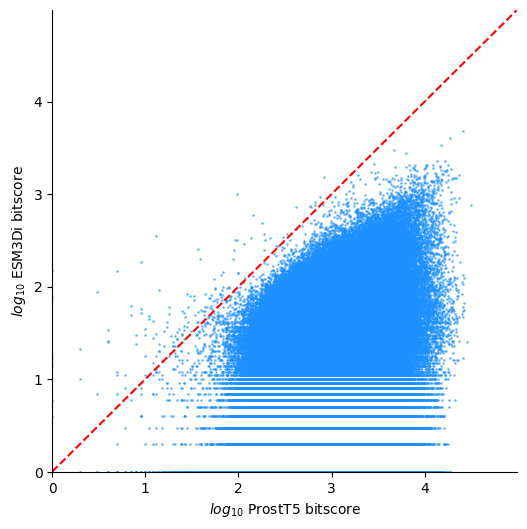

In [1]:
from matplotlib import pyplot as plt

x, y = [], []
with open('data/metavr/metavr_bitscores.tsv') as f:
    for line in f:
        _, prostt5_score, esm3di_score = line.strip().split()
        x.append(int(prostt5_score))
        y.append(int(esm3di_score))

# take log
from math import log10
x = [0 if score <= 0 else log10(score) for score in x]
y = [0 if score <= 0 else log10(score) for score in y]

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.figure(figsize=(6, 6))
plt.xlim(0, lim)
plt.ylim(0, lim)

# density plot
plt.scatter(x, y, alpha=0.5, s=1, color='dodgerblue')
plt.plot([0, lim], [0, lim], 'r--')

# set labels and title
plt.xlabel('$log_{10}$ ProstT5 bitscore')
plt.ylabel('$log_{10}$ ESM3Di bitscore')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()